In [30]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
import pandas as pd

In [31]:
cooperation = ctrl.Antecedent(np.arange(0, 100, 1), 'cooperation')
adaptivity = ctrl.Antecedent(np.arange(0, 100, 1), 'adaptivity')
forgiveness = ctrl.Antecedent(np.arange(0, 100, 1), 'forgiveness')
stohastic = ctrl.Antecedent(np.arange(0, 100, 1), 'stohastic')

c:\Users\Ognjen\AppData\Local\Programs\Python\Python311\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


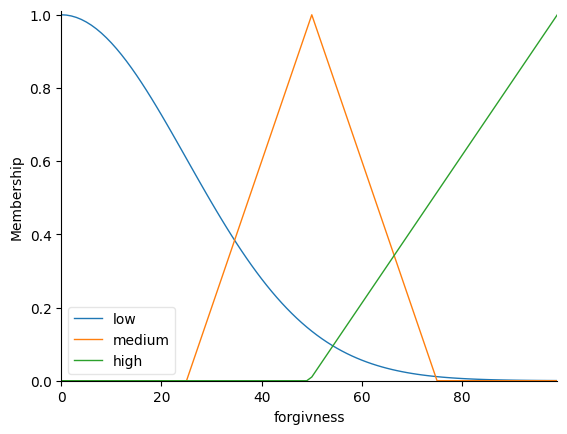

In [32]:
cooperation.automf(names=["low", "medium", "high"])
adaptivity.automf(names=["no", "yes"])
forgiveness.automf(names=["low", "medium", "high"])
forgiveness['low'] = fuzz.gaussmf(forgiveness.universe, 0, 25)
forgiveness['medium'] = fuzz.trimf(forgiveness.universe, [25, 50, 75])


stohastic.automf(names=["no", "sometimes", "always"])

forgiveness.view()

In [33]:
resulting_strategy = ctrl.Consequent(np.arange(0, 100, 1),'resulting_strategy')

In [34]:
resulting_strategy['D'] = fuzz.trimf(resulting_strategy.universe, [0, 25, 50])
resulting_strategy['C'] = fuzz.trimf(resulting_strategy.universe, [35, 75, 100])

In [35]:
rule1 = ctrl.Rule(cooperation['high'] & adaptivity['no'] & (forgiveness['medium'] or forgiveness['high']), resulting_strategy['D'])
rule2 = ctrl.Rule(forgiveness['low'] & cooperation['high'], resulting_strategy['C'])
rule3 = ctrl.Rule(stohastic['always'], resulting_strategy['D'])
rule4 = ctrl.Rule(cooperation['low'] | (cooperation['medium'] & forgiveness['low']), resulting_strategy['D'])

strategy_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
chosen_strategy = ctrl.ControlSystemSimulation(strategy_ctrl)

In [36]:
chosen_strategy.input['cooperation'] = 65
chosen_strategy.input['forgiveness'] = 1
chosen_strategy.input['adaptivity'] = 80
chosen_strategy.input['stohastic'] = 6

{'resulting_strategy': 43.8525144570177}
[0.24589942171929208, 0.22131286142544246]


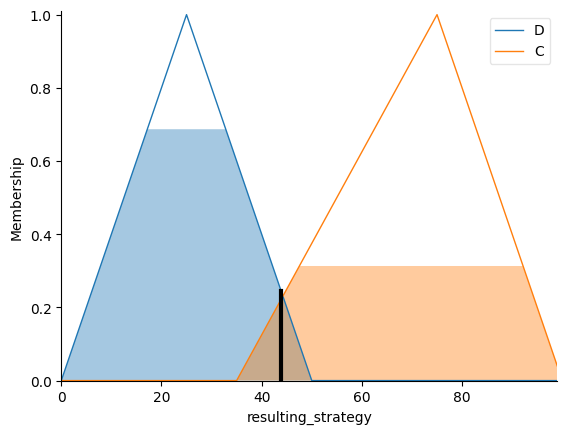

In [37]:
chosen_strategy.compute()

d_membership = fuzz.interp_membership(resulting_strategy.universe, resulting_strategy['D'].mf, chosen_strategy.output['resulting_strategy'])
c_membership = fuzz.interp_membership(resulting_strategy.universe, resulting_strategy['C'].mf, chosen_strategy.output['resulting_strategy'])
print(chosen_strategy.output)
print([d_membership, c_membership])
resulting_strategy.view(sim=chosen_strategy)

In [52]:
df = pd.DataFrame(columns=["Coop", "Adap", "Forg", "Stoh", "D", "C"])



In [57]:
od = chosen_strategy._get_inputs()

df = pd.concat([df, pd.DataFrame({
        "Coop": [od['cooperation']],
        "Adap": [od['adaptivity']],
        "Forg": [od['forgiveness']],
        "Stoh": [od['stohastic']],
        "D": [d_membership],
        "C": [c_membership]
    })], ignore_index=True)

In [59]:
print(df)

  Coop Adap Forg Stoh         D         C
0   65   80    1    6  0.245899  0.221313
1   65   80    1    6  0.245899  0.221313
